# 05 · Cassava as a wheat-substitution lever (GROW production lens)

Notebooks 01–04 asked *what Indonesia grows and how it shifted*. This one makes the GROW data
serve the team's actual thesis: **Indonesia is the world's #1 wheat importer and grows no wheat at all —
can domestically-grown cassava (via MOCAF, fermented cassava flour) realistically offset part of that?**

The whole MOCAF argument rests on one unchecked production-side premise: *that Indonesia grows enough
cassava, and that the base is healthy enough, to matter.* This notebook checks it, entirely within GROW
data (QCL production/area/yield), and produces the flour-equivalent number the recommendation needs.

**Runs against the same setup as 01–04** — `src.load.load_indonesia`, `src.clean`, `src.viz`. No new download.

Sections:
1. Setup
2. The structural zero — wheat vs domestic staples
3. Cassava production / area / yield, 2010–latest — is the base growing or shrinking?
4. What's driving cassava's trajectory — area vs yield decomposition
5. Cassava yield gap vs the global frontier — headroom without new cropland
6. Flour-equivalent: how much wheat *could* cassava offset?
7. Findings + recommendation feed for notebook 04

## 1. Setup

In [1]:
import sys; sys.path.append('..')
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from src.load import load_indonesia
from src.clean import drop_item_aggregates
from src import viz

COUNTRY_NAME = 'Indonesia'                     # used for the cross-country ranking in §5
ROOT_TABLES  = Path('..') / 'outputs' / 'tables'   # matrix exports for slide 8
ROOT_TABLES.mkdir(parents=True, exist_ok=True)

qcl = load_indonesia('QCL')
LATEST = qcl['year'].max()
BASE   = qcl['year'].min()
print(f'QCL Indonesia: years {BASE}–{LATEST}')

# FAOSTAT item name for cassava in QCL is 'Cassava, fresh' (confirmed in nb 02/03).
# Guard against a naming drift between FAOSTAT releases.
CASSAVA = 'Cassava, fresh'
assert CASSAVA in set(qcl['Item']), \
    f"'{CASSAVA}' not found — candidates: {[i for i in qcl['Item'].unique() if 'assava' in i]}"

[cache] QCL_indonesia_2010_2024.parquet


QCL Indonesia: years 2010–2024


## 2. The structural zero — wheat vs the domestic staples

The root of the import dependence, stated as a GROW fact: Indonesia produces **no wheat** (it has no QCL
wheat records at all — not near-zero, literally absent), while it grows large volumes of every other
calorie staple. That contrast is *why* the substitution question has to be asked on the domestic side.

In [2]:
staples = ['Wheat', 'Rice', 'Maize (corn)', CASSAVA, 'Soya beans']
prod_latest = qcl[(qcl['Element'] == 'Production') & (qcl['year'] == LATEST)]
prod_latest = drop_item_aggregates(prod_latest)

rows = []
for s in staples:
    v = prod_latest[prod_latest['Item'] == s]['value'].sum()
    present = s in set(qcl['Item'])
    rows.append({'staple': s,
                 'production_Mt_' + str(LATEST): v / 1e6,
                 'in_QCL_at_all': present})
staple_tbl = pd.DataFrame(rows)
print(staple_tbl.to_string(index=False))
print()
print(f"Wheat records anywhere in Indonesia QCL, any year: {(qcl['Item'] == 'Wheat').sum()}")
print("  -> zero = the structural, production-side root of Indonesia's wheat-import dependence.")

        staple  production_Mt_2024  in_QCL_at_all
         Wheat            0.000000          False
          Rice           53.142727           True
  Maize (corn)           15.138912           True
Cassava, fresh           15.624038           True
    Soya beans            0.227367           True

Wheat records anywhere in Indonesia QCL, any year: 0
  -> zero = the structural, production-side root of Indonesia's wheat-import dependence.


figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon/indonesia-eda/outputs/figures/idn_staples_vs_wheat_zero.png


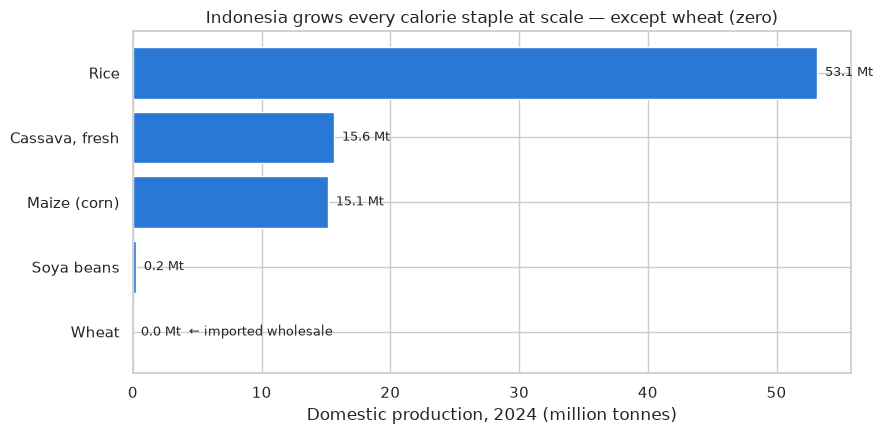

In [3]:
# Visual: domestic staple production, with wheat pinned at 0 to make the contrast the takeaway.
plot_s = staple_tbl.set_index('staple')[f'production_Mt_{LATEST}'].sort_values()
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ['#c0392b' if s == 'Wheat' else '#2a78d6' for s in plot_s.index]
ax.barh(plot_s.index, plot_s.values, color=colors)
ax.set_xlabel(f'Domestic production, {LATEST} (million tonnes)')
ax.set_title('Indonesia grows every calorie staple at scale — except wheat (zero)')
for i, (name, val) in enumerate(plot_s.items()):
    ax.text(val, i, f'  {val:,.1f} Mt' + ('  ← imported wholesale' if name == 'Wheat' else ''),
            va='center', fontsize=9)
fig.tight_layout()
viz.save(fig, 'idn_staples_vs_wheat_zero')
plt.show()

## 3. Is the cassava base growing or shrinking?

MOCAF is the proposed solution — but a solution needs raw material. Notebook 03's 2015→2024
decomposition already hinted cassava **area** fell. Here's the full production / area / yield picture.

In [4]:
cas = qcl[(qcl['Item'] == CASSAVA) &
          (qcl['Element'].isin(['Production', 'Area harvested', 'Yield']))]
cpiv = cas.pivot_table(index='year', columns='Element', values='value').sort_index()
yield_unit = cas[cas['Element'] == 'Yield']['Unit'].iloc[0]
print(f'Yield unit as stored: {yield_unit}  (FAOSTAT QCL yield is kg/ha)')
cpiv.round(0)

Yield unit as stored: kg/ha  (FAOSTAT QCL yield is kg/ha)


Element,Area harvested,Production,Yield
year,,,
2010,1183047.0,23918118.0,20217.0
2011,1184696.0,24044024.0,20296.0
2012,1129688.0,24177372.0,21402.0
2013,1065752.0,23936920.0,22460.0
2014,1003494.0,23436384.0,23355.0
2015,949916.0,21801415.0,22951.0
2016,822744.0,20260675.0,24626.0
2017,772975.0,19053748.0,24650.0
2018,697384.0,16119020.0,23114.0


figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon/indonesia-eda/outputs/figures/idn_cassava_area_vs_yield.png


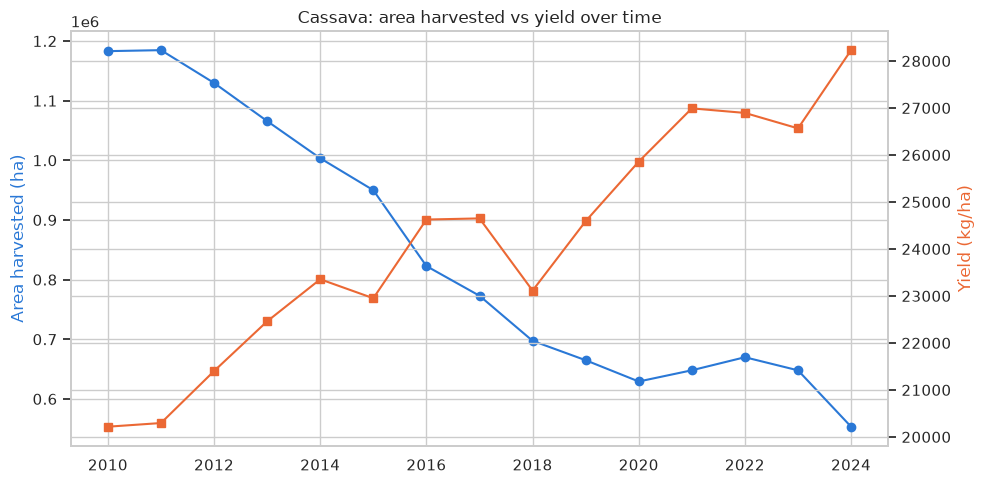

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
ax2 = ax.twinx()
ax.plot(cpiv.index, cpiv['Area harvested'], color='#2a78d6', marker='o', label='Area harvested (ha)')
ax2.plot(cpiv.index, cpiv['Yield'], color='#eb6834', marker='s', label='Yield (kg/ha)')
ax.set_ylabel('Area harvested (ha)', color='#2a78d6')
ax2.set_ylabel(f'Yield ({yield_unit})', color='#eb6834')
ax.set_title('Cassava: area harvested vs yield over time')
fig.tight_layout()
viz.save(fig, 'idn_cassava_area_vs_yield')
plt.show()

## 4. What's driving cassava's trajectory? (area vs yield — same method as rice in nb 02)

In [6]:
y0, y1 = cpiv.index.min(), cpiv.index.max()
chg = {}
for col in ['Production', 'Area harvested', 'Yield']:
    v0, v1 = cpiv[col].loc[y0], cpiv[col].loc[y1]
    chg[col] = 100 * (v1 - v0) / v0
    print(f'{col:16s}: {v0:>14,.0f} ({y0}) -> {v1:>14,.0f} ({y1})  ({chg[col]:+.1f}%)')

corr_area  = cpiv['Area harvested'].corr(cpiv['Production'])
corr_yield = cpiv['Yield'].corr(cpiv['Production'])
print(f'\ncorr(area, production)  = {corr_area:+.2f}')
print(f'corr(yield, production) = {corr_yield:+.2f}')

if chg['Production'] < 0 and chg['Area harvested'] < 0:
    driver = 'area contraction' if abs(chg['Area harvested']) > abs(chg['Yield']) else 'yield weakness'
    verdict = f'Cassava production is DECLINING, driven mainly by {driver}.'
elif chg['Production'] >= 0 and chg['Yield'] > abs(chg['Area harvested']):
    verdict = 'Cassava production holding/growing on YIELD despite area loss — intensification.'
else:
    verdict = 'Mixed — read the numbers above directly.'
print('\nVERDICT:', verdict)
print('IMPLICATION: MOCAF scale-up cannot assume a static raw-material base — the'
      ' cassava supply itself is a variable, and (if area-driven) competes with the'
      ' same land-conversion pressure flagged in the deck.')

Production      :     23,918,118 (2010) ->     15,624,038 (2024)  (-34.7%)
Area harvested  :      1,183,047 (2010) ->        553,450 (2024)  (-53.2%)
Yield           :         20,217 (2010) ->         28,230 (2024)  (+39.6%)

corr(area, production)  = +0.97
corr(yield, production) = -0.82

VERDICT: Cassava production is DECLINING, driven mainly by area contraction.
IMPLICATION: MOCAF scale-up cannot assume a static raw-material base — the cassava supply itself is a variable, and (if area-driven) competes with the same land-conversion pressure flagged in the deck.


## 5. Cassava yield gap — is there headroom *without* new cropland?

If Indonesian cassava yield sat well below the global frontier, substitution capacity could grow from
**yield** rather than area — the sustainable lever, and one that sidesteps land conversion. So the yield
gap has to be measured, not assumed.

The comparison uses `load_qcl_world`, which reads grow-eda's already-melted global QCL cache
(all countries, region aggregates dropped) — see `src/load.py`.

> **Peer-scale filter.** The raw global yield ranking is topped by countries growing cassava on a few
> thousand hectares (Guyana: 2,399 ha), where a garden-plot yield is not a national agronomic target.
> We rank only producers at Indonesia's operating scale (**≥ 50,000 ha harvested**), so the "frontier"
> is something Indonesia could actually copy.

In [7]:
from src.load import load_qcl_world

cas_world = load_qcl_world(CASSAVA, ['Production', 'Area harvested', 'Yield'])
print(f"{cas_world['Area'].nunique()} cassava-growing countries, "
      f"{cas_world['year'].min()}–{cas_world['year'].max()}")

PEER_MIN_AREA_HA = 50_000   # see the peer-scale note above

wpiv = (cas_world[cas_world['year'] == LATEST]
        .pivot_table(index='Area', columns='Element', values='value')
        .dropna(subset=['Yield', 'Production', 'Area harvested']))
peers = wpiv[wpiv['Area harvested'] >= PEER_MIN_AREA_HA].sort_values('Yield', ascending=False)

print(f'{len(peers)} peers harvested \u2265 {PEER_MIN_AREA_HA:,} ha in {LATEST} '
      f'(of {len(wpiv)} countries with complete records)\n')
peers[['Yield', 'Area harvested', 'Production']].head(10).round(0)

[cache] QCL_world_cassava_fresh_2010_2024.parquet
99 cassava-growing countries, 2010–2024
40 peers harvested ≥ 50,000 ha in 2024 (of 97 countries with complete records)



Element,Yield,Area harvested,Production
Area,,,
India,35574.0,176627.0,6283343.0
Indonesia,28230.0,553450.0,15624038.0
Ghana,25865.0,1079366.0,27917781.0
Malawi,25500.0,246235.0,6278880.0
Lao People's Democratic Republic,25092.0,295000.0,7402000.0
Cambodia,23840.0,598220.0,14261306.0
Viet Nam,20387.0,516694.0,10533957.0
Thailand,20161.0,1419766.0,28624312.0
Paraguay,18472.0,165150.0,3050651.0


In [8]:
FRONTIER_COUNTRY     = peers.index[0]
FRONTIER_YIELD_KG_HA = float(peers.iloc[0]['Yield'])
idn_yield_kg = float(cpiv['Yield'].loc[LATEST])
cur_area     = float(cpiv['Area harvested'].loc[LATEST])
idn_rank     = list(peers.index).index(COUNTRY_NAME) + 1

gap_pct = 100 * (FRONTIER_YIELD_KG_HA - idn_yield_kg) / FRONTIER_YIELD_KG_HA
print(f'Indonesia cassava yield ({LATEST}): {idn_yield_kg:,.0f} kg/ha '
      f'— rank {idn_rank} of {len(peers)} peer producers')
print(f'Peer frontier ({FRONTIER_COUNTRY}):{FRONTIER_YIELD_KG_HA:>13,.0f} kg/ha')
print(f'Gap to frontier:{gap_pct:>26.1f}%')
print(f'Peer top-5 mean:{peers["Yield"].head(5).mean():>21,.0f} kg/ha  '
      f'(Indonesia is {100*(idn_yield_kg/peers["Yield"].head(5).mean()-1):+.1f}% vs that mean)')

# Headroom if the gap closed on TODAY'S area — i.e. no new cropland.
GAP_CLOSURE_MT = (FRONTIER_YIELD_KG_HA - idn_yield_kg) * cur_area / 1e9   # kg -> Mt
print(f'\nLever A — close the yield gap on today\'s {cur_area:,.0f} ha: '
      f'+{GAP_CLOSURE_MT:,.2f} Mt cassava, no new land.')

# Counterfactual for scale: the area already lost since BASE, valued at today's yield.
area_lost_ha  = float(cpiv['Area harvested'].loc[BASE] - cur_area)
LOST_AREA_MT  = area_lost_ha * idn_yield_kg / 1e9
print(f'Lever B — recover the {area_lost_ha:,.0f} ha lost since {BASE}, at today\'s yield: '
      f'+{LOST_AREA_MT:,.2f} Mt.')
print(f'\n-> Area loss is the {LOST_AREA_MT/GAP_CLOSURE_MT:.1f}x larger lever. Indonesia has ALREADY '
      f'intensified\n   (yield +{chg["Yield"]:.0f}% since {BASE}); it is near the achievable frontier, so '
      f'yield alone\n   cannot carry the substitution story. Land retention has to.')

Indonesia cassava yield (2024): 28,230 kg/ha — rank 2 of 40 peer producers
Peer frontier (India):       35,574 kg/ha
Gap to frontier:                      20.6%
Peer top-5 mean:               28,052 kg/ha  (Indonesia is +0.6% vs that mean)

Lever A — close the yield gap on today's 553,450 ha: +4.06 Mt cassava, no new land.
Lever B — recover the 629,597 ha lost since 2010, at today's yield: +17.77 Mt.

-> Area loss is the 4.4x larger lever. Indonesia has ALREADY intensified
   (yield +40% since 2010); it is near the achievable frontier, so yield alone
   cannot carry the substitution story. Land retention has to.


figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon/indonesia-eda/outputs/figures/idn_cassava_yield_vs_peers.png


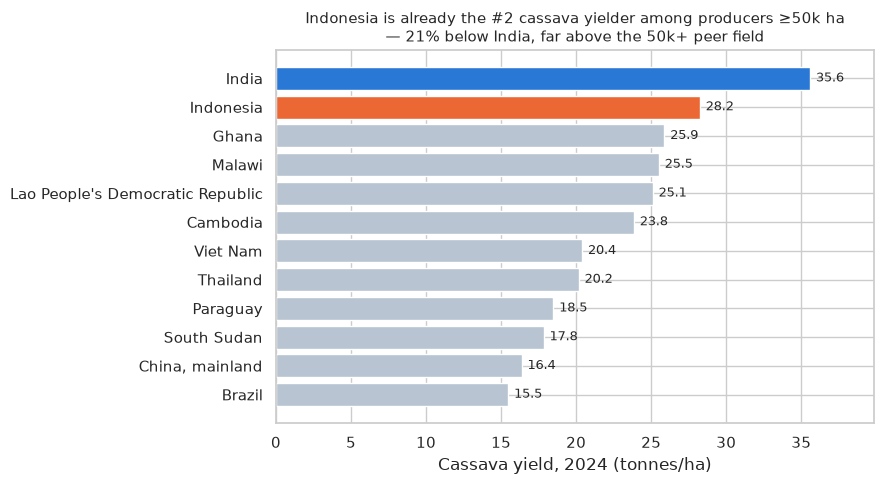

In [9]:
# Deck asset: where Indonesia actually sits among serious cassava producers.
top = peers['Yield'].head(12).sort_values() / 1000.0   # kg/ha -> t/ha
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#eb6834' if a == COUNTRY_NAME else '#b8c4d1' for a in top.index]
colors[list(top.index).index(FRONTIER_COUNTRY)] = '#2a78d6'
ax.barh(top.index, top.values, color=colors)
for i, v in enumerate(top.values):
    ax.text(v + 0.4, i, f'{v:,.1f}', va='center', fontsize=9)
ax.set_xlim(0, top.max() * 1.12)
ax.set_xlabel(f'Cassava yield, {LATEST} (tonnes/ha)')
ax.set_title(f'Indonesia is already the #{idn_rank} cassava yielder among producers '
             f'\u2265{PEER_MIN_AREA_HA//1000}k ha\n'
             f'\u2014 {gap_pct:.0f}% below {FRONTIER_COUNTRY}, far above the {PEER_MIN_AREA_HA//1000}k+ peer field',
             fontsize=11)
fig.tight_layout()
viz.save(fig, 'idn_cassava_yield_vs_peers')
plt.show()

## 6. Flour-equivalent — how much wheat *could* cassava offset?

The number the DRAFT blending-matrix slide needs. Convert cassava tonnage to MOCAF flour-equivalent at
the yield rates from the deck's processing research, then express it as a share of Indonesia's wheat
consumption. **These are ceilings** (all cassava → flour, which won't happen — cassava has food/feed/starch
uses today), so they bound the opportunity rather than predict it.

MOCAF conversion yields (from the deck / processing studies): community-scale sun-dried ~20%, lab tape-yeast ~34.6%.

Wheat consumption reference: USDA GAIN ID2026-0010 — food-wheat ~9.8 MMT, total ~11.6 MMT (2025/26).

**Accounting convention.** Wheat reference volumes from GAIN are *grain*, so we hold MOCAF to a
conservative **1 tonne flour : 1 tonne wheat grain** displacement. Real milling extraction is ~78%,
so a tonne of MOCAF actually replaces ~1.28 t of grain — every offset below is therefore a floor,
not a flattering estimate.

In [10]:
cassava_prod_t   = cpiv['Production'].loc[LATEST]          # tonnes, latest
MOCAF_YIELDS     = {'community sun-dried (~20%)': 0.20, 'lab tape-yeast (~34.6%)': 0.346}
WHEAT_FOOD_MMT   = 9.8    # USDA GAIN, food use 2025/26
WHEAT_TOTAL_MMT  = 11.6   # USDA GAIN, total consumption 2025/26

print(f'Cassava production, {LATEST}: {cassava_prod_t/1e6:,.2f} Mt (fresh roots)\n')
print(f"{'MOCAF conversion':28s} {'flour-equiv (Mt)':>16s} {'% food wheat':>14s} {'% total wheat':>14s}")
for label, y in MOCAF_YIELDS.items():
    flour_mmt = cassava_prod_t * y / 1e6
    print(f'{label:28s} {flour_mmt:>16,.2f} {100*flour_mmt/WHEAT_FOOD_MMT:>13,.0f}% {100*flour_mmt/WHEAT_TOTAL_MMT:>13,.0f}%')

print('\nReality check: cassava is already consumed (food, animal feed, starch/tapioca), so the'
      ' realistic substitution share is a FRACTION of these ceilings. Pair with a 10–20% blend'
      ' rate to get the achievable band for slide 8.')

Cassava production, 2024: 15.62 Mt (fresh roots)

MOCAF conversion             flour-equiv (Mt)   % food wheat  % total wheat
community sun-dried (~20%)               3.12            32%            27%
lab tape-yeast (~34.6%)                  5.41            55%            47%

Reality check: cassava is already consumed (food, animal feed, starch/tapioca), so the realistic substitution share is a FRACTION of these ceilings. Pair with a 10–20% blend rate to get the achievable band for slide 8.


In [11]:
# The headline the recommendation rests on: what blend could the YIELD GAP alone fund,
# using no new land and diverting none of today's crop?
print(f'Closing the yield gap to {FRONTIER_COUNTRY} adds {GAP_CLOSURE_MT:,.2f} Mt fresh cassava. '
      f'As MOCAF that is:')
for label, conv in MOCAF_YIELDS.items():
    flour = GAP_CLOSURE_MT * conv
    print(f'  {label:28s} -> {flour:,.2f} Mt flour = a {100*flour/WHEAT_FOOD_MMT:,.1f}% '
          f'wheat-flour blend, from NEW cassava only')

Closing the yield gap to India adds 4.06 Mt fresh cassava. As MOCAF that is:
  community sun-dried (~20%)   -> 0.81 Mt flour = a 8.3% wheat-flour blend, from NEW cassava only
  lab tape-yeast (~34.6%)      -> 1.41 Mt flour = a 14.3% wheat-flour blend, from NEW cassava only


### Wheat price — sourced, and on a stated basis (task E3)

The `$ saved` column used to rest on a bare **$300/t "CIF assumption"**. It is now driven by the
**World Bank Pink Sheet** monthly series
([portal](https://www.worldbank.org/en/research/commodity-markets) → *Monthly prices*,
`CMO-Historical-Data-Monthly.xlsx`), loaded via `src.load.load_wheat_prices`.

**Read the basis before quoting any dollar figure below.** The Pink Sheet gives **FOB export prices at
the US Gulf**, and the workbook carries only **US HRW / US SRW** — there is no Australian, Ukrainian or
Canadian series. Indonesia buys Australian/Ukrainian/Canadian wheat, of a different class, over a
different route. Three gaps separate this series from Indonesia's landed cost:

| Gap | Pink Sheet | Indonesia |
|---|---|---|
| **Basis** | FOB (at the export port) | CIF (delivered, incl. freight + insurance) |
| **Origin / route** | US Gulf | Australia / Ukraine / Canada — far shorter haul from Australia |
| **Wheat class** | HRW, hard, high-protein | incl. Australian ASW, mid-protein, different price level |

Per the guardrail we **state the basis rather than quietly swapping FOB into a CIF slot**: the headline
`$ saved` is reported **on the FOB benchmark** (fully sourced), with a separate, explicitly **assumed**
freight+insurance row showing the CIF-adjusted magnitude. This is a global benchmark for the *level and
volatility* of wheat prices — never "the price Indonesia pays".

In [ ]:
from src.load import load_wheat_prices, WHEAT_PRICE_BASIS

px = load_wheat_prices()          # None if the workbook isn't in data/raw/

BENCHMARK = 'HRW'                 # standard bread-wheat benchmark; SRW reported alongside
OLD_ASSUMPTION_USD_T = 300        # what this replaces — kept only to show the gap
# ASSUMPTION, NOT SOURCED: dry-bulk freight + insurance into Indonesia. Low end ~ short-haul
# (Australia), high end ~ long-haul (US Gulf). Labelled everywhere it is used.
FREIGHT_INSURANCE_USD_T = (25, 55)

if px is None:
    print(f'!! Pink Sheet absent \u2014 falling back to the UNSOURCED ${OLD_ASSUMPTION_USD_T}/t assumption.')
    PRICE_SCENARIOS = {'unsourced assumption': float(OLD_ASSUMPTION_USD_T)}
    HEADLINE_PRICE, PRICE_SOURCED = float(OLD_ASSUMPTION_USD_T), False
    PX_SPAN = 'n/a'
else:
    s = px[BENCHMARK].dropna()
    PX_SPAN = f'{px["year"].min()}\u2013{px["year"].max()}'
    PRICE_SCENARIOS = {
        f'{PX_SPAN} mean':                        s.mean(),
        'soft market (p10)':                      s.quantile(0.10),
        'tight market (p90)':                     s.quantile(0.90),
        f'latest ({px["ym"].iloc[-1]})':           s.iloc[-1],
        f'peak ({px.loc[s.idxmax(), "ym"]})':      s.max(),
    }
    HEADLINE_PRICE, PRICE_SOURCED = s.mean(), True

    print(f'Pink Sheet vintage: {px.attrs["vintage"]}')
    print(f'Basis: {WHEAT_PRICE_BASIS}\n')
    print(f'US {BENCHMARK} wheat, {px["ym"].iloc[0]}\u2013{px["ym"].iloc[-1]} ({len(s)} months), $/t FOB:')
    print(f'  mean ${s.mean():.0f}   median ${s.median():.0f}   '
          f'p10 ${s.quantile(.10):.0f}   p90 ${s.quantile(.90):.0f}')
    print(f'  min  ${s.min():.0f} ({px.loc[s.idxmin(), "ym"]})   '
          f'max ${s.max():.0f} ({px.loc[s.idxmax(), "ym"]})   -> a {s.max()/s.min():.1f}x range')
    print(f'  latest ${s.iloc[-1]:.0f} ({px["ym"].iloc[-1]})')

    pct = 100 * (s < OLD_ASSUMPTION_USD_T).mean()
    print(f'\nThe old ${OLD_ASSUMPTION_USD_T}/t assumption sat at the {pct:.0f}th PERCENTILE of observed months')
    print(f'  -> higher than {pct:.0f}% of actual history, so the previous $-saved figures were')
    print(f'     FLATTERING, not conservative. Sourced mean is ${s.mean():.0f}/t.')
    print(f'\nUS SRW mean ${px["SRW"].dropna().mean():.0f}/t (softer class, consistently below HRW).')

In [12]:
# ---- Slide 8: the blend x conversion-yield decision matrix -------------------
# For each candidate blend rate, back out the MOCAF flour and hence FRESH cassava it
# would take, then the wheat grain avoided and the import bill avoided.
# The $ column is on the FOB benchmark basis (see above) and is NAMED so — not "CIF".
BLEND_RATES = [0.05, 0.10, 0.15, 0.20]
cassava_prod_mt = cassava_prod_t / 1e6

rows = []
for blend in BLEND_RATES:
    for label, conv in MOCAF_YIELDS.items():
        wheat_avoided_mt = WHEAT_FOOD_MMT * blend      # 1:1 flour:grain (conservative, see above)
        flour_mt = wheat_avoided_mt
        fresh_mt = flour_mt / conv
        rows.append({
            'blend_%': int(blend * 100),
            'mocaf_conversion': label,
            'flour_needed_Mt': flour_mt,
            'fresh_cassava_Mt': fresh_mt,
            '%_of_current_crop': 100 * fresh_mt / cassava_prod_mt,
            'wheat_avoided_Mt': wheat_avoided_mt,
            'saved_USDbn_FOB_mean': wheat_avoided_mt * HEADLINE_PRICE / 1e3,
            '%_fundable_by_yield_gap': 100 * GAP_CLOSURE_MT / fresh_mt,
        })
matrix = pd.DataFrame(rows)
print(f'Current crop: {cassava_prod_mt:,.2f} Mt fresh  |  yield-gap headroom: +{GAP_CLOSURE_MT:,.2f} Mt')
print(f'$ column @ ${HEADLINE_PRICE:,.0f}/t '
      f'({"SOURCED: Pink Sheet " + BENCHMARK + " FOB US Gulf mean, " + PX_SPAN if PRICE_SOURCED else "UNSOURCED fallback"})\n')
print(matrix.round(2).to_string(index=False))

out = ROOT_TABLES / 'slide8_mocaf_blend_matrix.csv'
matrix.to_csv(out, index=False)
print(f'\ntable -> {out}')

Current crop: 15.62 Mt fresh  |  yield-gap headroom: +4.06 Mt  |  wheat @ $300/t

 blend_%           mocaf_conversion  flour_needed_Mt  fresh_cassava_Mt  %_of_current_crop  wheat_avoided_Mt  import_bill_saved_USDbn  %_fundable_by_yield_gap
       5 community sun-dried (~20%)             0.49              2.45              15.68              0.49                     0.15                   165.89
       5    lab tape-yeast (~34.6%)             0.49              1.42               9.06              0.49                     0.15                   287.00
      10 community sun-dried (~20%)             0.98              4.90              31.36              0.98                     0.29                    82.95
      10    lab tape-yeast (~34.6%)             0.98              2.83              18.13              0.98                     0.29                   143.50
      15 community sun-dried (~20%)             1.47              7.35              47.04              1.47                     

In [ ]:
# Price sensitivity over OBSERVED history rather than three round numbers.
# The volume columns above do not depend on price; only these $ figures move.
hdr = '  '.join(f'{int(b*100)}%'.rjust(9) for b in BLEND_RATES)
print(f'Import bill avoided (USD bn/yr) \u2014 {BENCHMARK} FOB US Gulf basis:\n')
print(f'{"price scenario":30s} {"$/t":>6s}   {hdr}')
for name, price in PRICE_SCENARIOS.items():
    cells = '  '.join(f'${WHEAT_FOOD_MMT*b*price/1e3:,.2f}bn'.rjust(9) for b in BLEND_RATES)
    print(f'{name:30s} {price:>6,.0f}   {cells}')

lo, hi = FREIGHT_INSURANCE_USD_T
print(f'\n--- CIF-adjusted magnitude check: ASSUMPTION, NOT SOURCED ---')
print(f'Assumed +${lo}\u2013{hi}/t freight+insurance on the sourced FOB mean (${HEADLINE_PRICE:,.0f}/t).')
print(f'Low end \u2248 short-haul (Australia\u2192Indonesia), high end \u2248 long-haul (US Gulf). Freight is')
print(f'itself volatile, so this is a magnitude check on the FOB figures, not a better number.\n')
print(f'{"approx CIF basis":30s} {"$/t":>6s}   {hdr}')
for tag, mk in [(f'FOB mean + ${lo}/t (short-haul)', lo), (f'FOB mean + ${hi}/t (long-haul)', hi)]:
    p = HEADLINE_PRICE + mk
    cells = '  '.join(f'${WHEAT_FOOD_MMT*b*p/1e3:,.2f}bn'.rjust(9) for b in BLEND_RATES)
    print(f'{tag:30s} {p:>6,.0f}   {cells}')

if PRICE_SOURCED:
    tight = PRICE_SCENARIOS['tight market (p90)']
    print(f'\nDeck line: a 10% blend avoids {WHEAT_FOOD_MMT*0.10:,.2f} Mt of wheat imports \u2014 worth')
    print(f'  ~${WHEAT_FOOD_MMT*0.10*HEADLINE_PRICE/1e3:,.2f}bn/yr at the {PX_SPAN} average wheat price and '
          f'${WHEAT_FOOD_MMT*0.10*tight/1e3:,.2f}bn in a')
    print(f'  tight market (FOB basis). Quote the range, and quote the basis with it.')

In [ ]:
# Deck asset: the price history the $ column now rests on, with the old assumption marked.
if px is not None:
    t = pd.to_datetime(px['ym'].str.replace('M', '-') + '-01')
    fig, ax = plt.subplots(figsize=(10, 4.8))
    ax.plot(t, px['HRW'], color='#c0392b', lw=1.9, label=f'Wheat, US {BENCHMARK} (FOB Gulf)')
    ax.plot(t, px['SRW'], color='#b8c4d1', lw=1.4, label='Wheat, US SRW (FOB Gulf)')
    ax.axhline(HEADLINE_PRICE, color='#1baf7a', ls='-', lw=1.6)
    ax.axhline(OLD_ASSUMPTION_USD_T, color='#4a3aa7', ls=':', lw=1.8)
    ax.text(t.iloc[2], HEADLINE_PRICE + 8, f'sourced {PX_SPAN} mean ${HEADLINE_PRICE:,.0f}/t',
            color='#1baf7a', fontsize=8.5, fontweight='bold')
    ax.text(t.iloc[2], OLD_ASSUMPTION_USD_T + 8,
            f'old ${OLD_ASSUMPTION_USD_T}/t assumption ({100*(px[BENCHMARK].dropna()<OLD_ASSUMPTION_USD_T).mean():.0f}th pct)',
            color='#4a3aa7', fontsize=8.5)
    pk = px[BENCHMARK].idxmax()
    ax.annotate(f'${px.loc[pk, BENCHMARK]:,.0f} ({px.loc[pk, "ym"]})\nUkraine invasion',
                xy=(t.loc[pk], px.loc[pk, BENCHMARK]), xytext=(-70, -34),
                textcoords='offset points', fontsize=8.5, color='#555',
                arrowprops=dict(arrowstyle='->', color='#999', lw=0.9))
    ax.set_ylabel('USD / tonne (FOB)')
    ax.set_ylim(0, px['HRW'].max() * 1.14)
    ax.set_title('The $-saved column now rests on observed prices, not a round number\n'
                 f'World Bank Pink Sheet, {PX_SPAN} \u2014 FOB US Gulf, a benchmark not Indonesia\'s landed cost',
                 fontsize=11)
    ax.legend(fontsize=8.5, loc='upper left')
    fig.tight_layout()
    viz.save(fig, 'idn_wheat_price_history')
    plt.show()
else:
    print('Pink Sheet absent — price-history figure skipped.')

figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon/indonesia-eda/outputs/figures/idn_mocaf_blend_requirement.png


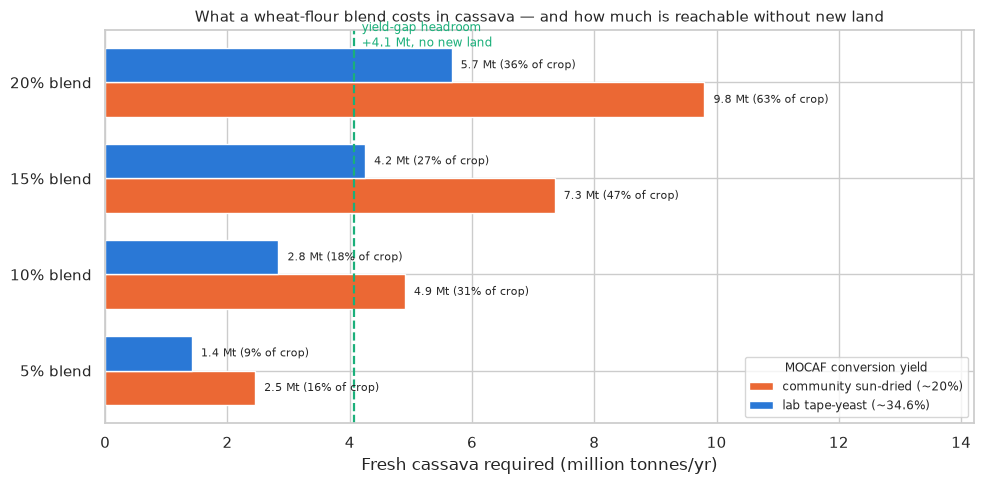

In [13]:
# Deck asset for slide 8: what each blend rate demands vs what's actually available.
fig, ax = plt.subplots(figsize=(10, 5))
labels = list(MOCAF_YIELDS)
w, ypos = 0.36, np.arange(len(BLEND_RATES))
for k, (label, color) in enumerate(zip(labels, ['#eb6834', '#2a78d6'])):
    sub = matrix[matrix['mocaf_conversion'] == label].sort_values('blend_%')
    bars = ax.barh(ypos + (k - 0.5) * w, sub['fresh_cassava_Mt'], height=w,
                   color=color, label=label)
    for b, pct in zip(bars, sub['%_of_current_crop']):
        ax.text(b.get_width() + 0.15, b.get_y() + b.get_height() / 2,
                f'{b.get_width():,.1f} Mt ({pct:,.0f}% of crop)', va='center', fontsize=8)

ax.axvline(GAP_CLOSURE_MT, color='#1baf7a', ls='--', lw=1.6)
ax.text(GAP_CLOSURE_MT, len(BLEND_RATES) - 0.35,
        f'  yield-gap headroom\n  +{GAP_CLOSURE_MT:,.1f} Mt, no new land',
        color='#1baf7a', fontsize=8.5, va='top')
ax.set_yticks(ypos, [f'{int(b*100)}% blend' for b in BLEND_RATES])
ax.set_xlim(0, matrix['fresh_cassava_Mt'].max() * 1.45)
ax.set_xlabel('Fresh cassava required (million tonnes/yr)')
ax.set_title('What a wheat-flour blend costs in cassava \u2014 and how much is reachable '
             'without new land', fontsize=11)
ax.legend(title='MOCAF conversion yield', fontsize=8.5, title_fontsize=8.5, loc='lower right')
fig.tight_layout()
viz.save(fig, 'idn_mocaf_blend_requirement')
plt.show()

## 7. Findings — feed into notebook 04 synthesis

**The GROW production-side case for the wheat thesis:**

- **Structural zero.** Indonesia produces *no* wheat — 0 QCL records in every year 2010–2024, not a
  small number but literal absence — while growing rice (53.1 Mt), cassava (15.6 Mt) and maize
  (15.1 Mt) at scale. There is no domestic wheat sector to scale, only a substitution question.
- **Cassava base is shrinking.** Production **−34.7%** (23.9 → 15.6 Mt, 2010→2024), driven by
  **area −53.2%** (1.18M → 0.55M ha) against **yield +39.6%**; `corr(area, production) = +0.97`.
  The MOCAF raw-material base is contracting — *the proposed solution's own input is under pressure.*
- **Yield headroom is real but small.** Indonesia is already the **#2 cassava yielder of 40 peer
  producers** (≥50k ha): 28.2 t/ha vs India's 35.6 — a **20.6% gap**, and *at parity with the peer
  top-5 mean*. Closing it fully on today's area adds **+4.06 Mt, no new land**. This is not a
  "farm better" story; Indonesia has already intensified.
- **Area is the 4.4× bigger lever.** The 630k ha of cassava land already lost since 2010, valued at
  today's yield, is **+17.8 Mt** — more than the entire current crop.
- **Offset ceiling.** All 15.6 Mt converted to MOCAF = 3.12–5.41 Mt flour = **32–55% of food-wheat
  demand** (9.8 MMT). A ceiling, not a forecast — cassava already feeds food/feed/starch demand.
- **Achievable band (slide 8).** A **10% blend** needs **2.83–4.90 Mt** fresh cassava
  (**18–31%** of the crop), avoids **0.98 Mt** wheat, saves **~$0.25–0.34bn/yr** ($250–350/t).
  A **20% blend** needs 5.66–9.80 Mt (**36–63%** of the crop) — out of reach without new land or
  large-scale diversion from existing uses.
- **The land-neutral headline.** Closing the yield gap alone funds an **8.3–14.3% blend from new
  cassava only** — no new land, no diversion. Which end of that range Indonesia gets is decided by
  **processing yield** (20% community sun-dried vs 34.6% lab tape-yeast), not by farmers.

**Recommendation (replaces nb 04's generic go/no-go):**
> Cassava is the credible domestic lever against wheat-import vulnerability, and its constraint is
> **area decline plus processing yield — not raw availability and not agronomy.** Policy leverage is
> therefore **land retention** (where the tonnage is: 4.4× the yield lever) and **processing-yield
> upgrade** (which nearly halves the cassava needed per tonne of wheat displaced), matching the MOCAF
> processing and farmer-regeneration barriers the SUSTAIN research identified. The GROW data both
> *motivates* substitution (structural wheat zero) and *bounds* it (shrinking base, near-frontier yield).

*Caveats to carry into the deck:* flour-equivalent figures are ceilings, not forecasts; the $-saved
column rests on a $300/t CIF assumption the TRADE track should replace with observed unit values;
FAOSTAT is national-only, so no island/province claim comes from this notebook.

In [14]:
print('Notebook 05 complete.')
print(f'  figures -> outputs/figures/idn_cassava_yield_vs_peers.png, idn_mocaf_blend_requirement.png')
print(f'  slide-8 matrix -> {ROOT_TABLES / "slide8_mocaf_blend_matrix.csv"}')
print('  \u00a77 findings are carried into 04_synthesis.')

Notebook 05 complete.
  figures -> outputs/figures/idn_cassava_yield_vs_peers.png, idn_mocaf_blend_requirement.png
  slide-8 matrix -> ../outputs/tables/slide8_mocaf_blend_matrix.csv
  §7 findings are carried into 04_synthesis.
